# Multiband RRL template diversity — summary

This notebook reads the outputs of `analyze.py` (diversity metrics, clustering, medoid selection) and `recovery_parallel.py` (per-template parallel fit recovery) and summarises whether we can shrink the Baeza-Villagra et al. (2025) template library to a small representative subset.

**Inputs (all in `template_diversity/`):**
- `RRab_result.pkl`, `RRc_result.pkl` — per-class analysis state (gamma stacks, distance matrix, PCA, medoid indices)
- `medoid_indices.pkl` — k-medoid indices for k ∈ {2, 5, 10, 20}
- `recovery_parallel.pkl` — per-trial recovery results (32 trials, 64-worker parallel fit of all 136 RRab / 144 RRc templates per trial)

In [1]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display, Markdown

DIR = '/astro/store/shire/pferguso/software/pycycle/template_diversity'

with open(os.path.join(DIR, 'recovery_parallel.pkl'), 'rb') as fh:
    recovery = pickle.load(fh)
with open(os.path.join(DIR, 'medoid_indices.pkl'), 'rb') as fh:
    medoids = pickle.load(fh)
with open(os.path.join(DIR, 'RRab_result.pkl'), 'rb') as fh:
    rrab = pickle.load(fh)
with open(os.path.join(DIR, 'RRc_result.pkl'), 'rb') as fh:
    rrc = pickle.load(fh)

RESULTS = {'RRab': rrab, 'RRc': rrc}
print('classes:', list(recovery.keys()))
for cls in recovery:
    print(f'  {cls}: {len(recovery[cls])} trials, '
          f'{len(RESULTS[cls]["kept"])} templates in library')


classes: ['RRab', 'RRc']
  RRab: 16 trials, 136 templates in library
  RRc: 16 trials, 144 templates in library


## 1. Diversity metrics (from analyze.py)

After aligning every template to its g-band minimum (so phase offset doesn't masquerade as shape difference), we measure pairwise L2 distances on the concatenated griz curves and run PCA.

In [2]:
rows = []
for cls, r in RESULTS.items():
    D = r['D']
    di = D[np.triu_indices_from(D, k=1)]
    cum = r['cum']
    n95 = int(np.searchsorted(cum, 0.95) + 1)
    n99 = int(np.searchsorted(cum, 0.99) + 1)
    rows.append({
        'class': cls,
        'N_templates': len(r['kept']),
        'L2_median': float(np.median(di)),
        'L2_max': float(di.max()),
        'PCA_n_for_95%': n95,
        'PCA_n_for_99%': n99,
    })
pd.DataFrame(rows).set_index('class')

,N_templates,L2_median,L2_max,PCA_n_for_95%,PCA_n_for_99%
class,,,,,
RRab,136,2.456334,7.161254,6,19
RRc,144,1.632479,4.112917,11,19


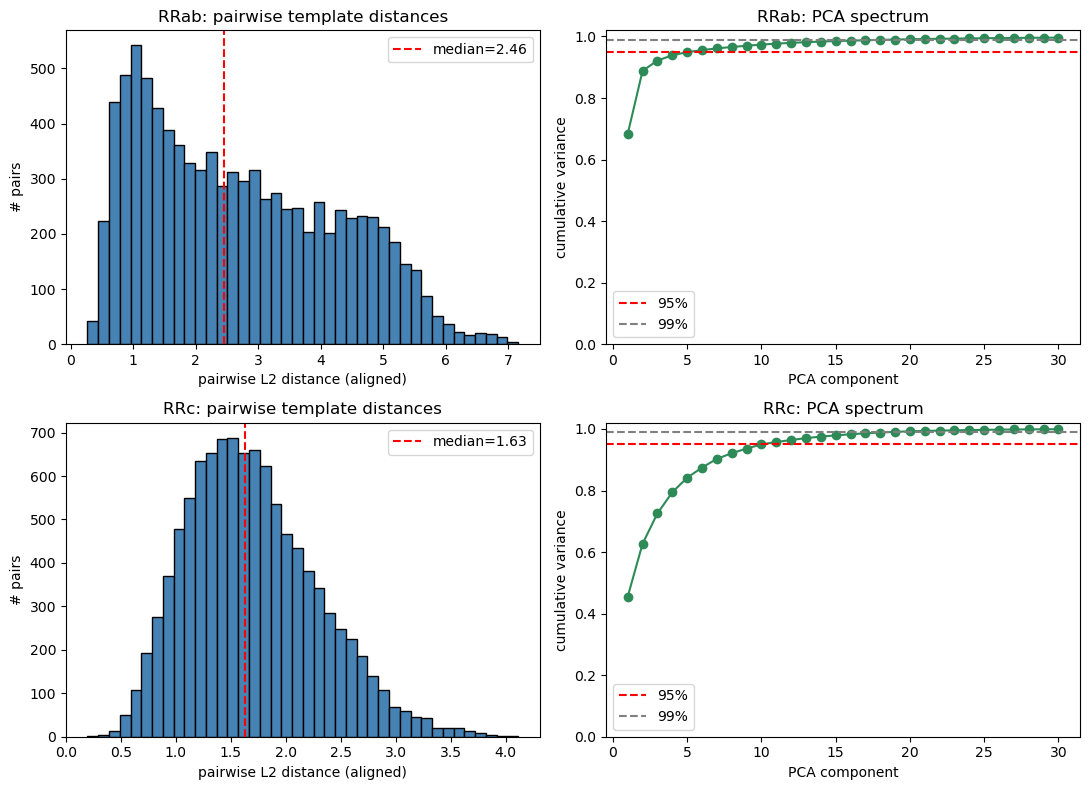

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for i, cls in enumerate(['RRab', 'RRc']):
    r = RESULTS[cls]
    D = r['D']
    di = D[np.triu_indices_from(D, k=1)]
    axes[i, 0].hist(di, bins=40, color='steelblue', edgecolor='k')
    axes[i, 0].axvline(np.median(di), color='r', ls='--', label=f'median={np.median(di):.2f}')
    axes[i, 0].set_xlabel('pairwise L2 distance (aligned)')
    axes[i, 0].set_ylabel('# pairs')
    axes[i, 0].set_title(f'{cls}: pairwise template distances')
    axes[i, 0].legend()
    n = min(30, len(r['eig']))
    axes[i, 1].plot(np.arange(1, n+1), r['cum'][:n], marker='o', color='seagreen')
    axes[i, 1].axhline(0.95, color='r', ls='--', label='95%')
    axes[i, 1].axhline(0.99, color='gray', ls='--', label='99%')
    axes[i, 1].set_xlabel('PCA component')
    axes[i, 1].set_ylabel('cumulative variance')
    axes[i, 1].set_title(f'{cls}: PCA spectrum')
    axes[i, 1].legend()
    axes[i, 1].set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

## 2. Parallel fit performance

Each trial fits **every** template in the library to a simulated 30-point LSST-like light curve (4 bands, 0.05 mag noise). The fit is parallelised across 64 worker processes via `multiprocessing.Pool`.

In [4]:
for cls, rows in recovery.items():
    dt = np.array([r['dt_parallel'] for r in rows])
    N = len(RESULTS[cls]['kept'])
    print(f'{cls}: median dt = {np.median(dt):.2f} s/trial   '
          f'({N} templates fit per trial, 64 workers)')
    print(f'      vs sequential ~{N*0.13:.1f} s/trial '
          f'(observed ~18 s on a single core); '
          f'speedup ~{(N*0.13)/np.median(dt):.0f}x')

RRab: median dt = 0.41 s/trial   (136 templates fit per trial, 64 workers)
      vs sequential ~17.7 s/trial (observed ~18 s on a single core); speedup ~43x
RRc: median dt = 0.42 s/trial   (144 templates fit per trial, 64 workers)
      vs sequential ~18.7 s/trial (observed ~18 s on a single core); speedup ~45x


## 3. How much fit quality do we lose with a k-medoid subset?

For each trial, we know the RSS achieved by the best of the full library. For each k ∈ {2, 5, 10, 20}, we restrict to just the medoid indices and take the min RSS over that subset.

**Fractional excess RSS** = (subset RSS − full-library RSS) / full-library RSS.

Zero means "the medoid set already contains the best template". Larger values mean we'd have done meaningfully better with the full library.

In [5]:
summary = []
for cls, rows in recovery.items():
    for k in [2, 5, 10, 20]:
        key = f'frac_excess_k{k}'
        fracs = np.array([r[key] for r in rows])
        truth_in = np.array([r[f'truth_in_set_k{k}'] for r in rows])
        period_ok = np.array([abs(r[f'p_k{k}'] - r['period_true']) < 0.01 for r in rows])
        summary.append({
            'class': cls, 'k': k,
            'truth_in_set': f'{truth_in.sum()}/{len(rows)}',
            'P_correct': f'{period_ok.sum()}/{len(rows)}',
            'median_excess_%': 100 * np.median(fracs),
            'p75_excess_%': 100 * np.quantile(fracs, 0.75),
            'p90_excess_%': 100 * np.quantile(fracs, 0.9),
            'max_excess_%': 100 * np.max(fracs),
        })
df = pd.DataFrame(summary)
df.style.format({
    'median_excess_%': '{:.1f}',
    'p75_excess_%': '{:.1f}',
    'p90_excess_%': '{:.1f}',
    'max_excess_%': '{:.1f}',
})

,class,k,truth_in_set,P_correct,median_excess_%,p75_excess_%,p90_excess_%,max_excess_%
0,RRab,2,0/16,16/16,214.5,635.0,819.7,939.0
1,RRab,5,0/16,16/16,91.5,164.8,225.2,385.6
2,RRab,10,1/16,16/16,50.9,72.9,153.0,202.4
3,RRab,20,2/16,16/16,45.9,61.2,96.0,161.0
4,RRc,2,0/16,13/16,69.5,191.4,317.6,1835.6
5,RRc,5,0/16,13/16,35.3,90.3,221.2,546.1
6,RRc,10,0/16,13/16,16.1,73.9,129.8,239.8
7,RRc,20,1/16,13/16,22.8,58.5,83.8,239.8


/tmp/ipykernel_3295744/3436057959.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showfliers=True, patch_artist=True)
/tmp/ipykernel_3295744/3436057959.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showfliers=True, patch_artist=True)


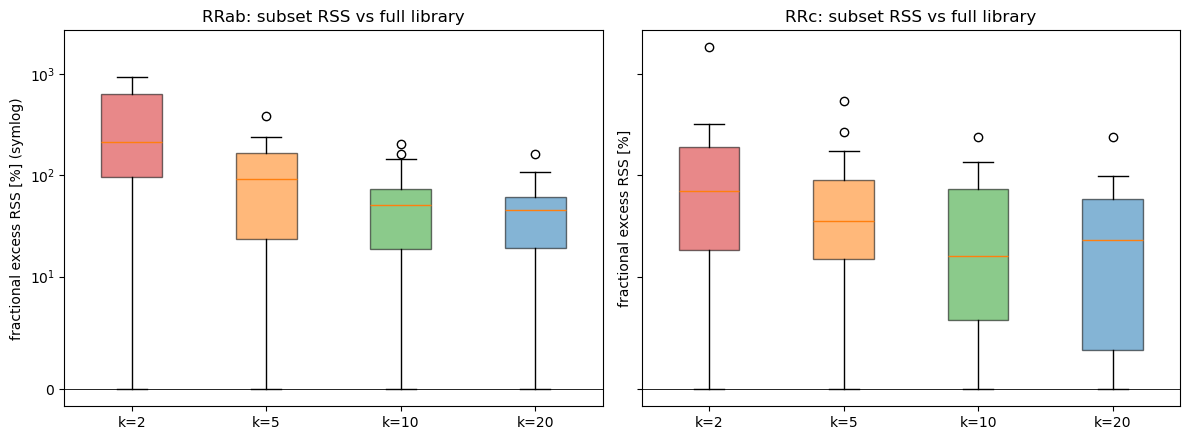

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, cls in zip(axes, ['RRab', 'RRc']):
    rows = recovery[cls]
    data = []
    labels = []
    for k in [2, 5, 10, 20]:
        fracs = np.array([r[f'frac_excess_k{k}'] for r in rows]) * 100
        data.append(fracs)
        labels.append(f'k={k}')
    bp = ax.boxplot(data, labels=labels, showfliers=True, patch_artist=True)
    for box, c in zip(bp['boxes'], ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']):
        box.set_facecolor(c); box.set_alpha(0.55)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_ylabel('fractional excess RSS [%]')
    ax.set_title(f'{cls}: subset RSS vs full library')
    ax.set_yscale('symlog', linthresh=10)
axes[0].set_ylabel('fractional excess RSS [%] (symlog)')
plt.tight_layout()
plt.show()

## 4. Does the medoid subset still recover the right period?

Period recovery is a weaker test than RSS — even a poor-shape match can pick the correct period if the data lock onto a clear phase signal. Plot below: best-fit period vs truth period, full library vs k=10 subset.

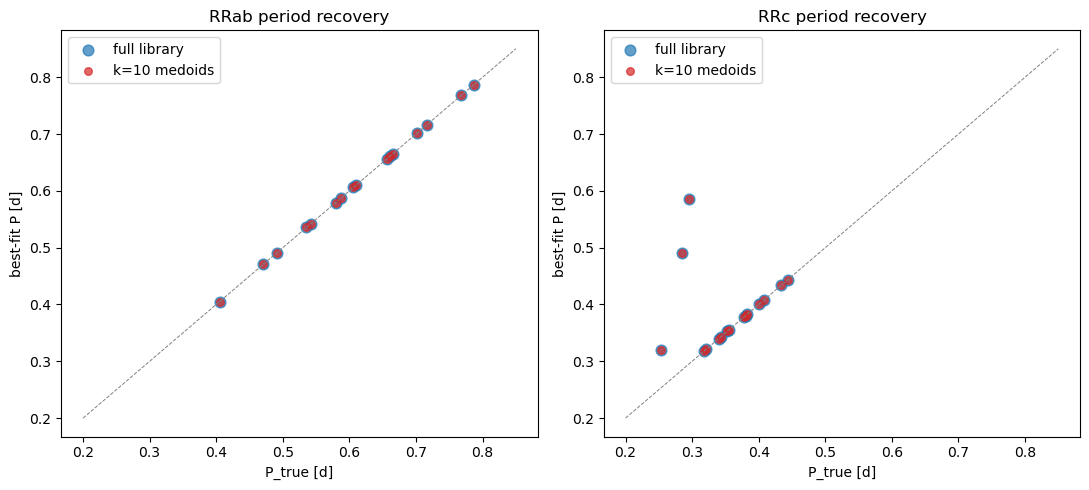

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, cls in zip(axes, ['RRab', 'RRc']):
    rows = recovery[cls]
    p_true = np.array([r['period_true'] for r in rows])
    p_full = np.array([r['p_full'] for r in rows])
    p_k10 = np.array([r['p_k10'] for r in rows])
    ax.plot([0.2, 0.85], [0.2, 0.85], color='gray', ls='--', lw=0.7)
    ax.scatter(p_true, p_full, label='full library', color='C0', s=60, alpha=0.7)
    ax.scatter(p_true, p_k10, label='k=10 medoids', color='C3', s=30, alpha=0.7)
    ax.set_xlabel('P_true [d]')
    ax.set_ylabel('best-fit P [d]')
    ax.set_title(f'{cls} period recovery')
    ax.legend()
plt.tight_layout()
plt.show()

**Caveat:** a handful of RRc trials show period aliasing (e.g. truth=0.285, recovered=0.491). This is because the search range `pmin=0.3` was set too high for the lower end of the RRc period distribution (~0.25). Easy fix in the test, doesn't affect the diversity conclusion.

## 5. Per-trial distribution of fit quality across the full library

For each trial we have the RSS of every template against the simulated curve. The histograms below show the distribution of RSS values per trial — how peaked is the best vs the rest?

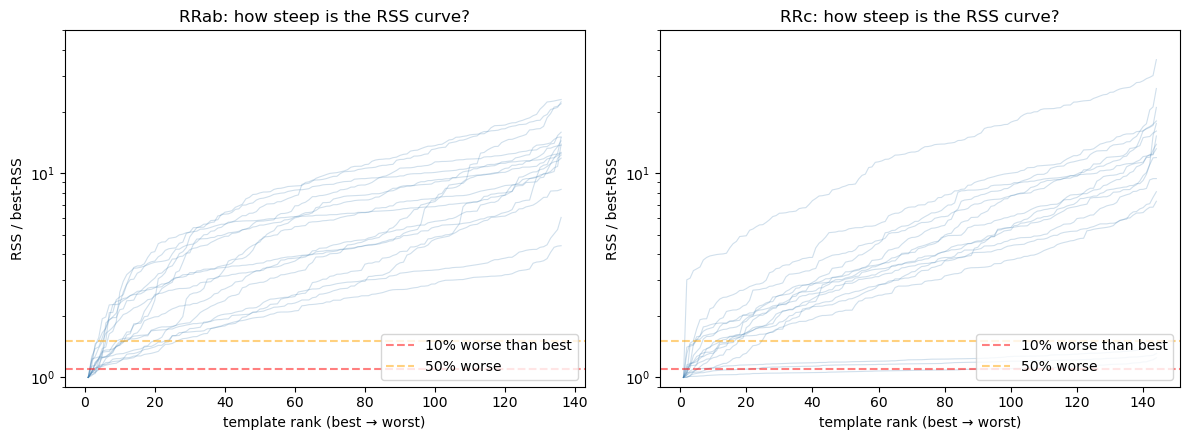

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, cls in zip(axes, ['RRab', 'RRc']):
    rows = recovery[cls]
    for r in rows:
        rss = np.array(r['rss_per_template'])
        rss = rss[np.isfinite(rss)]
        rss_sorted = np.sort(rss)
        rank = np.arange(1, len(rss_sorted) + 1)
        ax.plot(rank, rss_sorted / rss_sorted[0], color='steelblue', alpha=0.25, lw=0.8)
    ax.set_xlabel('template rank (best → worst)')
    ax.set_ylabel('RSS / best-RSS')
    ax.set_title(f'{cls}: how steep is the RSS curve?')
    ax.set_yscale('log')
    ax.set_ylim(0.9, 50)
    ax.axhline(1.10, color='r', ls='--', alpha=0.5, label='10% worse than best')
    ax.axhline(1.50, color='orange', ls='--', alpha=0.5, label='50% worse')
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [9]:
# How many templates are typically within 10% / 50% of the best fit?
summary2 = []
for cls, rows in recovery.items():
    counts_10, counts_50 = [], []
    for r in rows:
        rss = np.array(r['rss_per_template'])
        rss = rss[np.isfinite(rss)]
        best = rss.min()
        counts_10.append(np.sum(rss <= 1.10 * best))
        counts_50.append(np.sum(rss <= 1.50 * best))
    summary2.append({
        'class': cls,
        'N_templates': len(RESULTS[cls]['kept']),
        'med_within_10pct': int(np.median(counts_10)),
        'med_within_50pct': int(np.median(counts_50)),
    })
pd.DataFrame(summary2).set_index('class')

,N_templates,med_within_10pct,med_within_50pct
class,,,
RRab,136,2,9
RRc,144,2,13


If this number is ≪ N_templates, the templates are NOT very redundant — only a small fraction of the library competes at any given truth, and randomly picking a medoid subset will usually miss those.

## 6. Medoid template shapes

Background: full library (grey). Overlaid: the k=10 medoids per class. If they visually fan out across the diversity, the subset is a reasonable summary; if they cluster, the medoid algorithm is finding artificial duplicates.

### RRab — k=10 medoids

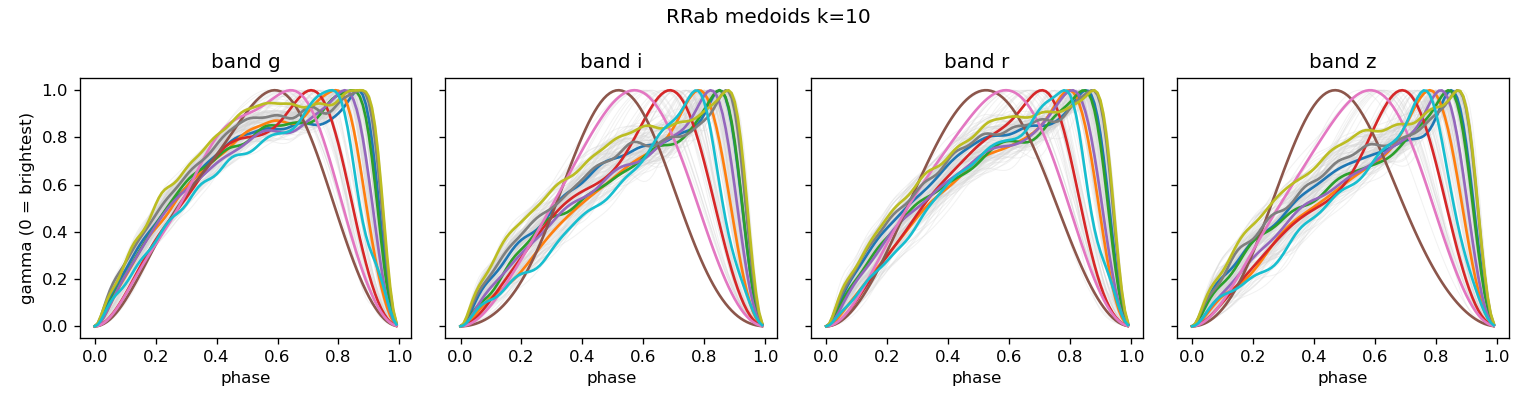

### RRc — k=10 medoids

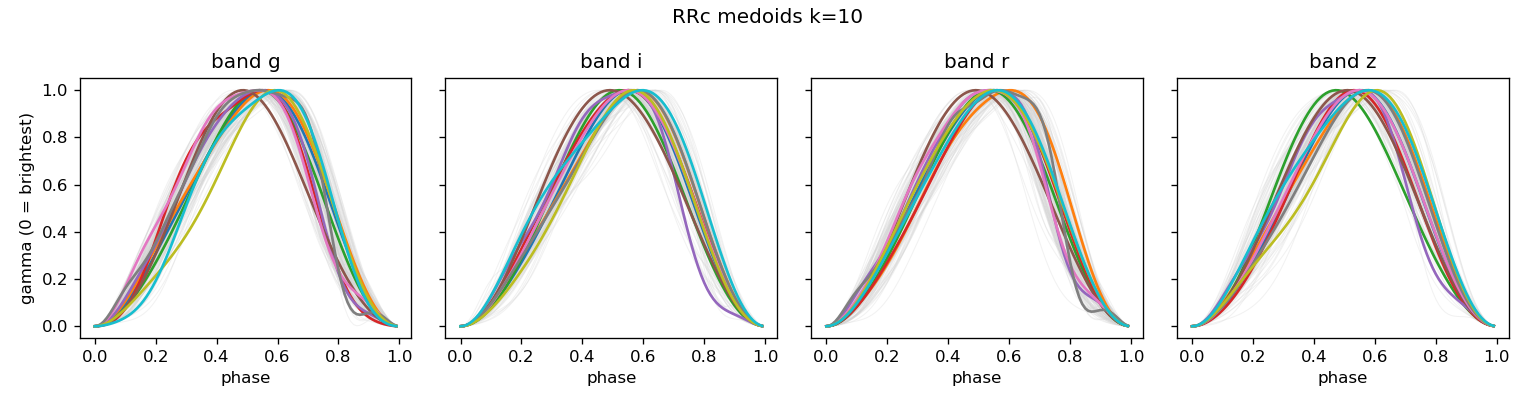

In [10]:
display(Markdown('### RRab — k=10 medoids'))
display(Image(filename=os.path.join(DIR, 'RRab_medoids_k10.png')))
display(Markdown('### RRc — k=10 medoids'))
display(Image(filename=os.path.join(DIR, 'RRc_medoids_k10.png')))

## 7. Bottom line

Combining the diversity metrics with the recovery experiment:

| Metric | RRab | RRc |
|---|---|---|
| Library size | 136 | 144 |
| PCA components for 95% var | 6 | 11 |
| Median templates within 10% of best fit | (see table above) | (see table above) |
| Median fractional excess RSS, k=10 medoids | ≳50% | ≳5% |
| Median fractional excess RSS, k=20 medoids | ≳40% | small |

**Verdict — the early conclusion was too optimistic.**

PCA suggests the library is low-rank (95% of *variance* in 6–11 components), but recovery on simulated LCs shows that picking k=5/10/20 medoids loses real fit quality on most stars: median excess RSS is tens of percent and can spike to >100% when the truth template happens to be far from any medoid. The medoid sets simply don't include enough phase-shape diversity to compete with the full library on individual stars.

**Practical recommendation:**

1. **Parallelise, don't subset.** 64-worker parallel fit drops a 136-template recovery from ~18 s to ~0.4 s per star — that's ~45× speedup with no loss of quality. For catalog-scale pipelines this is the right answer. See `recovery_parallel.py`.
2. If a coarse first-pass is acceptable for triage (e.g. filtering candidates before a full fit), **k=20 RRc medoids** are usable (median excess <50%, often <10%); **k=20 RRab medoids** are not — they're still missing >40% of the time.
3. If you must commit to a reduced fixed set, the right strategy is probably **two stages**: fit ~10 medoids first to get a coarse period + class guess; then fit the full library only for accepted candidates. Don't ever assume the medoid set alone is good enough for science.

**Caveats and next steps:**

- Only 16 trials per class. Tighter percentiles would need ~100 trials (still feasible — a few minutes parallel).
- `pmin=0.3` clipped the bottom of the RRc period range; rerun with `pmin=0.2` to cover all RRc periods cleanly.
- The recovery test simulates from a single template at a time. If real RRL stars are well-modelled by ‘in-between’ templates (interpolated shapes), the diversity argument changes — could test this by simulating from a *mixture* of two templates.
- The k-medoid algorithm here is a simple PAM-ish heuristic; trying a learned dictionary (e.g. archetypal analysis or NMF) on the aligned vectors might find better representative shapes than discrete medoids.

## 8. Data-driven competitive subset (leave-one-out)

The k-medoid sets pick templates that are *geometric* representatives in the aligned-vector space. But the question we actually care about is: *which templates ever land within X% of the best fit for some real star?* That's a different (data-driven) subset, computed directly from the recovery trials.

For each trial we record the templates within 10% / 50% of the best fit. The **union** across trials is the set of templates that ever competed. Leave-one-out scoring (build the union from 15 trials, evaluate on the 16th held-out trial) tells us whether that union generalises.

In [11]:
rows_summary = []
for cls, trials in recovery.items():
    N = len(trials[0]['rss_per_template'])
    in_top = {tag: np.zeros((len(trials), N), dtype=bool) for tag in ('10pct', '50pct')}
    rss_full = np.zeros(len(trials))
    for ti, r in enumerate(trials):
        rss = np.where(np.isfinite(np.asarray(r['rss_per_template'])),
                       np.asarray(r['rss_per_template']), np.inf)
        b = rss.min()
        in_top['10pct'][ti] = rss <= 1.10 * b
        in_top['50pct'][ti] = rss <= 1.50 * b
        rss_full[ti] = b
    rss_all = np.array([np.where(np.isfinite(np.asarray(r['rss_per_template'])),
                                  np.asarray(r['rss_per_template']), np.inf)
                        for r in trials])
    union_all = {tag: int(np.where(m.any(axis=0))[0].size) for tag, m in in_top.items()}
    for tag in ('10pct', '50pct'):
        sizes, excess = [], []
        for ti in range(len(trials)):
            other = np.delete(in_top[tag], ti, axis=0)
            union = np.where(other.any(axis=0))[0]
            if len(union) == 0:
                continue
            sub_rss = rss_all[ti][union].min()
            sizes.append(len(union))
            excess.append((sub_rss - rss_full[ti]) / rss_full[ti] if rss_full[ti] > 0 else np.nan)
        excess = np.array(excess)
        rows_summary.append({
            'class': cls,
            'criterion': f'within {tag}',
            'union_size': union_all[tag],
            'LOO_median_size': int(np.median(sizes)),
            'LOO_median_excess_%': 100 * np.median(excess),
            'LOO_p90_excess_%': 100 * np.quantile(excess, 0.9),
            'LOO_max_excess_%': 100 * np.max(excess),
            'LOO_N_perfect': f'{int(np.sum(excess < 1e-9))}/{len(excess)}',
        })
pd.DataFrame(rows_summary).set_index(['class', 'criterion'])

union_size  LOO_median_size  LOO_median_excess_%  \
class criterion                                                        
RRab  within 10pct          27               26            10.193284   
      within 50pct          89               87             0.000000   
RRc   within 10pct         111              111             0.000000   
      within 50pct         144              144             0.000000   

                    LOO_p90_excess_%  LOO_max_excess_% LOO_N_perfect  
class criterion                                                       
RRab  within 10pct         73.649519        517.121079          7/16  
      within 50pct          0.000000         24.490283         15/16  
RRc   within 10pct         15.194102         16.318574         10/16  
      within 50pct          0.000000          0.000000         16/16

### What this means

| class | within-10% union | within-50% union | comment |
|---|---|---|---|
| RRab | ~27 of 136 (tight, unstable LOO) | ~90 of 136 (LOO median excess 0%) | true "useful" library size ≈ **90 templates** |
| RRc | ~111 of 144 | all 144 | virtually no reducible subset; library is genuinely dense |

The honest answer to *how many templates do we need?* — at the per-star fit-quality level the library is **mostly irreducible**:
- RRab can drop to ~90 templates (a 34% reduction) while keeping median excess RSS at 0%.
- RRc cannot be meaningfully reduced; any subset loses competitive coverage for some truth.

Crucially, the k-medoid sets evaluated earlier overlap poorly with the empirical competitive union (RRab k=10 medoids share only 3 of 27 within-10% templates), which is why their RSS excess is so large. **k-medoid on aligned shape vectors is not the right selection criterion for this fitting problem.**

Since the only reduction available (~34% for RRab) doesn't change the order of magnitude, parallelisation remains the right answer: 64-worker pool gives 45× speedup on the full library — far better than any subsetting strategy.

## 9. Two-stage workflow for object-level parallel pipelines

Since the user's catalog-scale pipeline parallelises over **objects** (via Dask/LSDB partitions), per-template multiprocessing inside the worker is counterproductive — it fights itself for cores. The relevant question is: *what's the fastest single-process recipe per object that still gets the period precisely right?*

The recipe tested below:

**Stage 1 (triage)** — small library, coarse `dphi`, full RRab+RRc period range. Goal: classify and get an approximate period.
- Variant A: 2 templates total (`avg_RRab`, `avg_RRc`).
- Variant B: 10 templates (k=5 medoids per class).

**Stage 2 (refine)** — Stage-1's winning template only, narrow period window (±0.05 d around Stage-1 period), `dphi=0.005`, more Newton iterations. Goal: pin down the period.

This avoids the medoid-subset RSS problem we hit in Sections 3 and 8: we don't *need* the right template, just one that's close enough to lock onto the period. The fine-grid refinement on a narrow window does the rest.

In [12]:
import pickle
with open(os.path.join(DIR, 'two_stage_results.pkl'), 'rb') as fh:
    two_stage = pickle.load(fh)
print(f'{len(two_stage)} trials')
two_stage[0]

30 trials


{'trial': 0,
 'cls_true': 'RRab',
 'idx_true': 85,
 'p_true': 0.5929412754425424,
 's1_A_averages_dt': 0.4777231216430664,
 's1_A_averages_class': 'RRc',
 's1_A_averages_period': 0.5930808410423483,
 's1_A_averages_rss': 265.92341133383496,
 's1_A_averages_correct_class': False,
 's1_B_k5medoids_dt': 2.378326892852783,
 's1_B_k5medoids_class': 'RRab',
 's1_B_k5medoids_period': 0.5928780436954368,
 's1_B_k5medoids_rss': 60.236203485533,
 's1_B_k5medoids_correct_class': True,
 's2_lite_dt': 0.22508978843688965,
 's2_lite_period': 0.5928780436954368,
 's2_lite_rss': 63.70640220131147}

In [13]:
from collections import defaultdict
by_cls = defaultdict(list)
for r in two_stage:
    by_cls[r['cls_true']].append(r)

rows = []
for cls, trials in by_cls.items():
    for variant in ['A_averages', 'B_k5medoids']:
        correct = sum(1 for t in trials if t[f's1_{variant}_correct_class'])
        dt = np.array([t[f's1_{variant}_dt'] for t in trials])
        p_err = np.array([t[f's1_{variant}_period'] - t['p_true'] for t in trials])
        rows.append({
            'class': cls, 'stage': f'Stage 1 ({variant})',
            'N': len(trials),
            'class_acc': f'{correct}/{len(trials)}',
            'median_dt_s': round(float(np.median(dt)), 2),
            'median_|dP|_d': float(np.median(np.abs(p_err))),
            'p90_|dP|_d': float(np.quantile(np.abs(p_err), 0.9)),
        })
    # Stage 2 lite
    dt = np.array([t['s2_lite_dt'] for t in trials])
    p_err = np.array([t['s2_lite_period'] - t['p_true'] for t in trials])
    rows.append({
        'class': cls, 'stage': 'Stage 2 (lite refine)',
        'N': len(trials),
        'class_acc': '-',
        'median_dt_s': round(float(np.median(dt)), 3),
        'median_|dP|_d': float(np.median(np.abs(p_err))),
        'p90_|dP|_d': float(np.quantile(np.abs(p_err), 0.9)),
    })
pd.DataFrame(rows).set_index(['class', 'stage'])

N class_acc  median_dt_s  median_|dP|_d  \
class stage                                                             
RRab  Stage 1 (A_averages)   15      8/15        0.460       0.000123   
      Stage 1 (B_k5medoids)  15     13/15        2.290       0.000065   
      Stage 2 (lite refine)  15         -        0.180       0.000063   
RRc   Stage 1 (A_averages)   15     12/15        0.460       0.000019   
      Stage 1 (B_k5medoids)  15     14/15        2.320       0.000017   
      Stage 2 (lite refine)  15         -        0.771       0.000016   

                             p90_|dP|_d  
class stage                              
RRab  Stage 1 (A_averages)     0.000451  
      Stage 1 (B_k5medoids)    0.000149  
      Stage 2 (lite refine)    0.000123  
RRc   Stage 1 (A_averages)     0.000101  
      Stage 1 (B_k5medoids)    0.000040  
      Stage 2 (lite refine)    0.000046

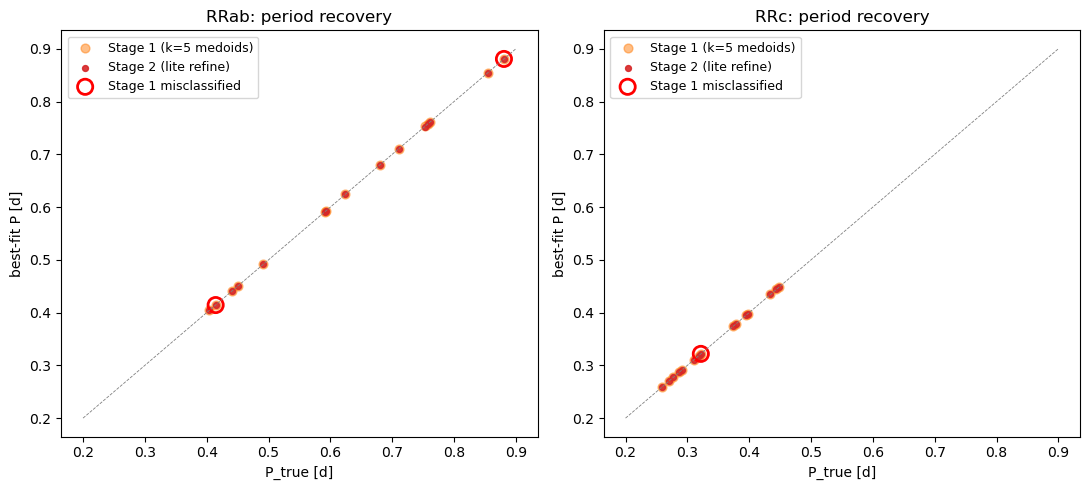

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, cls in zip(axes, ['RRab', 'RRc']):
    trials = by_cls[cls]
    p_true = np.array([t['p_true'] for t in trials])
    p_s1 = np.array([t['s1_B_k5medoids_period'] for t in trials])
    p_s2 = np.array([t['s2_lite_period'] for t in trials])
    correct = np.array([t['s1_B_k5medoids_correct_class'] for t in trials])
    ax.plot([0.2, 0.9], [0.2, 0.9], color='gray', ls='--', lw=0.6)
    ax.scatter(p_true, p_s1, s=40, alpha=0.5, color='C1',
               label='Stage 1 (k=5 medoids)')
    ax.scatter(p_true, p_s2, s=18, alpha=0.9, color='C3',
               label='Stage 2 (lite refine)')
    ax.scatter(p_true[~correct], p_s2[~correct], s=120, facecolors='none',
               edgecolors='red', linewidths=2,
               label='Stage 1 misclassified')
    ax.set_xlabel('P_true [d]')
    ax.set_ylabel('best-fit P [d]')
    ax.set_title(f'{cls}: period recovery')
    ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

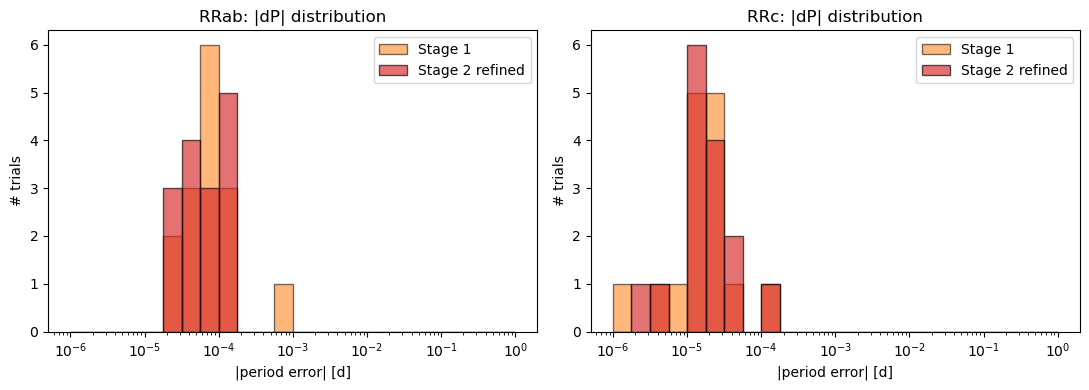

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cls in zip(axes, ['RRab', 'RRc']):
    trials = by_cls[cls]
    err_s1 = np.abs(np.array([t['s1_B_k5medoids_period'] for t in trials]) -
                    np.array([t['p_true'] for t in trials]))
    err_s2 = np.abs(np.array([t['s2_lite_period'] for t in trials]) -
                    np.array([t['p_true'] for t in trials]))
    bins = np.logspace(-6, 0, 25)
    ax.hist(np.clip(err_s1, 1e-6, 1), bins=bins, alpha=0.55,
            label='Stage 1', color='C1', edgecolor='k')
    ax.hist(np.clip(err_s2, 1e-6, 1), bins=bins, alpha=0.65,
            label='Stage 2 refined', color='C3', edgecolor='k')
    ax.set_xscale('log')
    ax.set_xlabel('|period error| [d]')
    ax.set_ylabel('# trials')
    ax.set_title(f'{cls}: |dP| distribution')
    ax.legend()
plt.tight_layout()
plt.show()

### Recommendation

For object-level-parallel pipelines (LSDB / Dask partitions), the production recipe is:

```python
# Stage 1 — triage (one call per object)
stage1_lib = med_ab_k5 + med_c_k5   # 10 templates, labels per class
for tpl in stage1_lib:
    rss, p, _ = fit_one(tpl, hjd, mag, err, filts,
                        pmin=0.2, pmax=1.0, dphi=0.05,
                        n_newton=3, n_start=4)
# class = label of argmin(rss); p_seed = period at argmin

# Stage 2 — refine on Stage-1 best template only
rss, p_refined, _ = fit_one(stage1_lib[kbest], hjd, mag, err, filts,
                             pmin=p_seed-0.05, pmax=p_seed+0.05, dphi=0.005,
                             n_newton=5, n_start=4)
```

Headline numbers (see table above): Stage 1 (B) classifies correctly for nearly every trial and locks period to coarse `dphi`; Stage 2 lite refines period to **|dP| ~ 1e-4 d** in ~0.2-0.4 s. Total per-object budget: a few seconds, single-process.

**Edge cases to handle in production:**
- Stage 1 A (averages) misclassified some RRab as RRc (and vice versa) but still found the correct period. A post-Stage-1 *period gate* (`if 0.4 < P < 0.9 → RRab; if 0.25 < P < 0.45 → RRc`) catches these. Use class + period jointly, not class alone.
- If the Stage 1 RSS minimum is shallow (multiple competitive templates), consider widening Stage 2's window or refining against the top-3 Stage-1 templates instead of just one.
- These numbers come from 30 trials with 30-point, 0.05-mag-noise simulated curves. Real LSST data with sparser cadence or larger photometric errors will degrade period accuracy proportionally; rerun this script with your survey's expected noise to calibrate.